# Conducción de calor en una barra de metal.

**Objetivos.**
* Explicar un problema de conducción de calor en una dimensión que tiene solución analítica.
* Transformar el problema original en un sistema de ecuaciones lineales mediante el método de diferencias finitas.
* Resolver el sistema de ecuaciones y comparar con la solución analítica.
  
**Trabajo realizado con el apoyo del Programa UNAM-DGAPA-PAPIME, proyectos PE101019, PE101922 y PE106025.**

[![License: CC BY-SA 4.0](https://img.shields.io/badge/License-CC_BY--SA_4.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)


<div class="alert alert-danger">

**Ojo**. Ejecuta la siguiente celda para que todo lo que sigue funcione correctamente.
</div>

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from macti.eval import Quiz

plt.style.use('seaborn-v0_8-whitegrid') 
quiz = Quiz("001_conduccion_1D", "notebooks", "local")

## Descripción.

En el siguiengte video se observa como una barra de metal es expuesta a una fuente de calor en su extremo izquierdo. El cambio de temperatura se representa con colores: rojo mayor temperatura, morado menor temperatura. El calor se transfiere por un fenómeno físico conocido como **conducción.**

<table>
  <tr>
    <td><video src="./conduccion_1D.mp4" width="320" controls></video></td>
  </tr>
</table>


## Modelo matemático.
Para el problema de conducción de calor en una barra podemos considerar un modelo matemático en una dimensión en la dirección $x$ y lo escribimos como sigue

$$
-\kappa \frac{d^2 T}{d x^2} = q \tag{1}
$$

donde $\kappa$ representa la conductividad térmica y $q$ una fuente de energía calorífica.

### Condiciones de frontera.

La barra tiene una temperatura $T_A$ en su extremo izquierdo y otra temperatura $T_B$ en su extremo derecho, observa la figura 1. 

<figure>
  <div style="text-align: center;">
  <img src='dominio_1D.svg' width=450px height=auto>
  </div>
  <figcaption>Figura 1. Esquema de la barra identificando su longitud $L$, su conductividad térmica $\kappa$ y sus condiciones de frontera $T_A$ y $T_B$. </figcaption>
</figure>

Este tipo de condiciones se conocen como condiciones de frontera de primer tipo o Dirichlet y se escriben matemáticamente como sigue

$$
\begin{eqnarray}
T & = & T_A \;\;\; \text{en} \;\;\; x = 0\\
T & = & T_B \;\;\; \text{en} \;\;\; x = L\\
\end{eqnarray}
$$


## Solución analítica.

En este caso particular, la solución se puede obtener de manera analítica de tal manera que es posible encontrar una función $T(x)$ que proporciona la temperatura en cada posición $x$. La solución analítica es:

$$
T(x) = \left(\frac{T_B - T_A}{L} + \frac{q}{2\kappa} \left(L - x\right) \right)x + T_A \tag{2}
$$

En la sección <a href="#sol_analitica">Obtención de la solución analítica</a> de esta notebook se muestra cómo se deduce esta fórmula.

<div class="alert alert-info">

### Ejemplo 1.

Vamos a usar los siguientes datos en los ejemplos y ejercicios que continuan:

- $\kappa = 1000$ [W /m $^o$C]
- $L = 0.5$ [m]
- $T_A = 500$ [$^o$C]
- $T_B = 100$ [$^o$C]
- $q = 0$

En la celda siguiente implementamos la función `sol_analitica()` para evaluar la fórmula $(2)$. 
Posteriormente, definimos variables para cada uno de los parámetros físicos antes mencionados.

**Nota**. Ejectua las dos celdas que siguen y observa el resultado.

</div>

In [5]:
def sol_analitica(x, TA, TB, q, L, k):
    """
    Calcula la temperatura usando la fórmula (2).
    """
    return ((TB - TA)/L + q /(2*k) * (L - x) ) * x + TA

In [6]:
# Definimos los parámetros físicos del problema
k = 1000
L = 0.5
TA = 500
TB = 100
q = 0

print("Parámetros físicos:")
print(f"k  = {k}")
print(f"L  = {L}")
print(f"TA = {TA}")
print(f"TB = {TB}")
print(f"q  = {q}")

Parámetros físicos:
k  = 1000
L  = 0.5
TA = 500
TB = 100
q  = 0


<div class="alert alert-info">

### Ejemplo 2.

En este ejemplo evalúamos la solución analítica unsado la función `sol_analitica()` con los datos definidos en el **ejemplo 1** y se hace una gráfica.

**Nota.** Observa que el resultado se calcula en 100 puntos almacenados en el arreglo de coordenadas `xa` y las temperaturas calculadas se almacenan en el arreglo `Ta`.

</div>

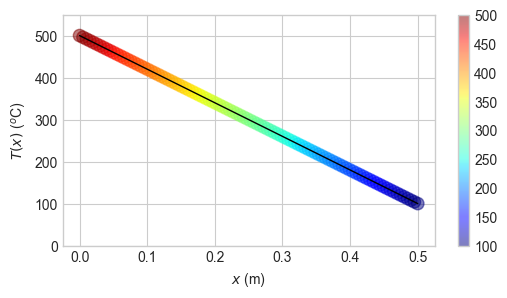

In [7]:
# Puntos donde se calcula la solución analítica
xa = np.linspace(0, L, 100)

# Calculamos la temperatura con la solución analítica en los 100 puntos
Ta = sol_analitica(xa, TA, TB, q, L, k) 

# Graficamos de la solución
plt.figure(figsize=(6,3))
plt.plot(xa, Ta, color='k', lw =1.0)
s = plt.scatter(xa, Ta, c=Ta, cmap='jet', s=80, alpha=0.5)

# Configuración de la gráfica
plt.xlabel("$x$ (m)")
plt.ylabel("$T(x)$ ($^o$C)")
plt.ylim(0,550)
plt.colorbar(s) 
plt.grid(True)
plt.show()

<div class="alert alert-success">
    
**Pregunta.**
¿Puedes explicar el resultado de la solución en términos físicos y matemáticos?
</div>

<div class="alert alert-info">

### Ejemplo 3.

Evaluar la solución analítica mostrada en la ecuación $(2)$ pero ahora considerando que la barra recibe un flujo de calor $q$ en cada uno de sus puntos. En este caso los datos son los siguientes:
- $\kappa = 0.5$ [W /m $^o$C]
- $L = 0.02$ [m]
- $T_A = 100$ [$^o$C]
- $T_B = 200$ [$^o$C]
- $q = 5 \times 10^6$ [W/m$^3$]  (Flujo de calor)

</div>

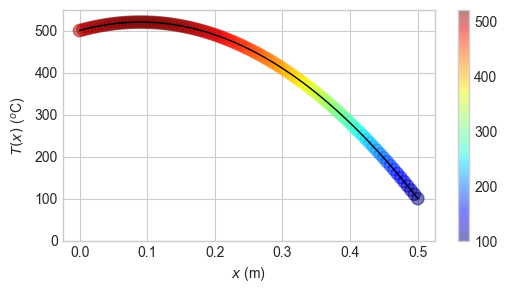

In [8]:
# Modificamos el parámetro q
q = 5e+6 

# Calculamos la temperatura con la solución analítica en los 100 puntos
Ta = sol_analitica(xa, TA, TB, q, L, k) 

# Graficamos de la solución
plt.figure(figsize=(6,3))
plt.plot(xa, Ta, color='k', lw =1.0)
s = plt.scatter(xa, Ta, c=Ta, cmap='jet', s=80, alpha=0.5)

# Configuración de la gráfica
plt.xlabel("$x$ (m)")
plt.ylabel("$T(x)$ ($^o$C)")
plt.ylim(0,550)
plt.colorbar(s) 
plt.grid(True)
plt.show()

<div class="alert alert-success">

**Preguntas:**
* ¿Por qué cambia el resultado con respecto al **ejemplo 2**?
* ¿Puedes explicar el resultado de la solución en términos físicos y matemáticos?
</div>

<a id="sol_numerica"></a>
## Solución numérica

La ecuación diferencial parcial $(1)$ también se puede resolver usando el método numérico conocido como **diferencias finitas**. Cuando aplicamos este método numérico, la ecuación $(1)$ se transforma en un sistema de ecuaciones donde cada ecuación es válida para un solo punto de la barra. Observa la siguiente figura:

<figure>
  <div style="text-align: center;">
  <img src='malla_df_nodos_numerados.svg' width=450px height=auto>
  </div>
  <figcaption>

Figura 2. Sobre la barra se identifican puntos donde se calcula la temperatura (cuadros grises). Estos puntos se llaman nodos. Hay dos puntos especiales que son los extremos de la barra y se conocen como fronteras del dominio (cuadros blancos). `N` es el número de nodos internos (sin considerar las fronteras), en esta figura `N = 4`. La distancia entre nodos es equidistante e igual a $h$. 
  </figcaption>
</figure>

De acuerdo con la figura 2, la temperatura se va a calcular en los nodos `1`, `2`, `3` y `4`. En las fronteras, nodos `0` y `5`, se tienen temperaturas conocidas, que son las condiciones de frontera. Con esta numeración de los nodos y las condiciones de frontera, el método de diferencias finitas genera el siguiente sistema de ecuaciones:

<table>
  <tr>
    <td>
$$
\begin{eqnarray}
-T_0 + 2T_1 - T_2 & = & Q \\
-T_1 + 2T_2 - T_3 & = & Q \\
-T_2 + 2T_3 - T_4 & = & Q \\
-T_3 + 2T_4 - T_5 & = & Q 
\end{eqnarray}
$$
    </td>
    <td>
$$
\Longrightarrow 
$$
</td>
    <td>
$$
\underbrace{
\left(
\begin{array}{ccccccccc}
 2 &-1 & 0 & 0 \\ 
-1 & 2 &-1 & 0 \\ 
 0 &-1 & 2 &-1 \\ 
 0 & 0 &-1 & 2 \\
\end{array}\right)}_{\mathbf{A}}
\underbrace{
\left(
\begin{array}{c}
T_1 \\ T_2 \\ T_3 \\ T_4
\end{array}\right)}_{\mathbf{T}} = 
\underbrace{
\left(
\begin{array}{c}
Q + T_A \\ Q \\ Q \\ Q + T_{B}
\end{array}\right)}_{\mathbf{Q}} \tag{3}
$$
    </td>
  </tr>
</table

donde $Q = \dfrac{q h^2}{\kappa}$, $T_0 = T_A$ y $T_{5} = T_B$. 

Observa que el sistema lineal de ecuaciones se puede escribir en términos de una matriz $\mathbf{A}$, un vector de incógnitas $\mathbf{T}$ y un lado derecho $\mathbf{Q}$ también conocido como *Right Hand Side* (RHS). 

Cuando se resuelve este sistema de ecuaciones se obtienen las temperaturas en los nodos interiores `1`, `2`, `3` y `4`.

Si quieres saber cómo se aplica el método de diferencias finitas para obtener el sistema de ecuaciones lineales $(3)$, revisa la sección <a href="#dif_finitas">Diferencias finitas</a> de esta notebook.

<div class="alert alert-info">

### Ejemplo 4.

En la siguiente celda se implementa una función de Python que genera la matriz y el lado derecho del sistema. 

1. Ejecuta la celda siguiente para definir la función `sistema_lineal()`.
2. Posteriormente, prueba la función usando los datos definidos en el **ejemplo 1** y para `N = 2`. 

</div>

In [9]:
def sistema_lineal(TA, TB, q, L, k, N):
    # Cálculo de la separación entre puntos
    h = L / (N+1)

    # Definición inicial del vector del lado derecho (RHS)
    Q = np.full(N, q * h**2 / k)
    
    # Definición inicial de la matriz
    A = np.identity(N)

    # Primer renglón de la matriz
    A[0,0] = 2
    A[0,1] = -1

    # Renglones internos de la matriz
    for i in range(1,N-1):
        A[i,i-1] = -1
        A[i,i]   = 2
        A[i,i+1] = -1

    # Último renglón de la matriz
    A[-1,-2] = -1
    A[-1,-1] = 2
    
    # Aplicación de las condiciones de frontera
    Q[0]  += TA
    Q[-1] += TB
    
    # Regresa la matriz y el RHS
    return A, Q

In [10]:
# Definición del valor de N.
N = 2

# Prueba de la función
A, Q = sistema_lineal(TA, TB, q, L, k, N)

print(f"Matriz del sistema: \n{A}")
print(f"RHS: \n{Q}")

Matriz del sistema: 
[[ 2. -1.]
 [-1.  2.]]
RHS: 
[638.88888889 238.88888889]


<div class="alert alert-success">

### Ejercicio 1.

Realiza lo siguiente:

1. Cálcula la matriz y el RHS con la función `sistema_lineal()` usando los datos del **ejemplo 2** para `N = 4`. 
2. Una vez que has generado la matriz y el RHS del sistema, resuélvelo usando la función [`np.linalg.solve()`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html).
3. Almacena la matriz y el RHS en los arreglos `A` y `Q`, y la solución en el arreglo `T`.

**Nota.** Observa que el arreglo `T` se define en todos los nodos, incluyendo las fronteras. Por lo tanto, cuando calcules la solución esta deberá almacenarse solo en los índices internos del arreglo usando indexación. Revisa el tema de indexación en Python [aquí](https://repomacti.github.io/introduccion_python/notebooks/05_cadenas.html#sec-e-indexacion-cadenas).
</div>

El directorio :/Users/luiggi/GitSites/00_NEAT/macti_notes/notebooks/.ans/SolucionSistemasLineales_01 ya existe
Respuestas y retroalimentación almacenadas.
Matriz del sistema: 
[[ 2. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  2. -1.]
 [ 0.  0. -1.  2.]]
RHS: 
[550.  50.  50. 150.]
Solución: 
[500. 520. 490. 410. 280. 100.]


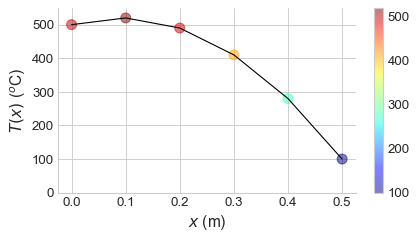

In [34]:
# Definimos el número de puntos donde calcularemos la solución.
N = 4

# Definimos el arreglo para almacenar la solución numérica
# Observa que se crea el arreglo de tamaño N+2 para incluir las fronteras.
T = np.zeros(N+2)

# Valores de la tempertura en las fronteras
T[0]  = TA
T[-1] = TB

# Definimos los puntos donde se calcula la solución numérica
# Observa que se crea el arreglo de tamaño N+2 para incluir las fronteras.
x = np.linspace(0, L, N+2)

### BEGIN SOLUTION
# Calculamos la temperatura con el método numérico en los N puntos
A, Q = sistema_lineal(TA, TB, q, L, k, N)

# Calculamos la temperatura resolviendo el sistema lineal
T[1:-1] = np.linalg.solve(A, Q)

import macti.eval as meval

file_answer = meval.FileAnswer()

feed1 = """Checa que todos los argumentos que recibe la función sistema_lineal(),
estén bien definidos con los valores adecuados. Revisa los datos que regresa dicha
función y su orden para asignarlos correctamente.
"""
feed2 = """El arreglo T está incorrecto.
Checa que hayas usado correctamente la función np.linalg.solve() con los 
argumentos adecuados y en el orden correcto. También revisa los índices de
el arreglo donde almacenas la solución (deberías iniciar en el segundo 
elemento (1) y terminar en el penúltimo (-1) esto debido a las condiciones
de frontera).
"""
file_answer.write("1", A, "La matriz A está incorrecta.\n" + feed1)
file_answer.write("2", Q, "El vector Q es incorrecto.\n" + feed1)
file_answer.write("3", T, feed2)
file_answer.to_file("001_conduccion_1D")
### END SOLUTION
#
# Calculamos la temperatura con el método numérico en los N puntos
#A, Q = sistema_lineal(....)

# Calculamos la temperatura resolviendo el sistema lineal
#T[1:-1] = np.linalg.solve(...)

# Imprimimos la matriz, el RHS y la solución
print(f"Matriz del sistema: \n{A}")
print(f"RHS: \n{Q}")
print(f"Solución: \n{T}")

# Graficamos la solución
plt.figure(figsize=(6,3))
plt.plot(x, T, color='k', lw =1.0)
s = plt.scatter(x, T, c=T, cmap='jet', s=80, alpha=0.5)

# Configuración de la gráfica
plt.xlabel("$x$ (m)")
plt.ylabel("$T(x)$ ($^o$C)")
plt.ylim(0,550)
plt.colorbar(s) 
plt.grid(True)
plt.show()

In [36]:
quiz.eval_numeric("1", A.flatten())
quiz.eval_numeric("2", Q)
quiz.eval_numeric("3", T)

――――――――――――――――――――――――――――――――――――――――
1 | Tu resultado es correcto.
――――――――――――――――――――――――――――――――――――――――
――――――――――――――――――――――――――――――――――――――――
2 | Tu resultado es correcto.
――――――――――――――――――――――――――――――――――――――――
――――――――――――――――――――――――――――――――――――――――
3 | Tu resultado es correcto.
――――――――――――――――――――――――――――――――――――――――


<div class="alert alert-success">

**Pregunta.**
¿Qué tan parecida es la solución numérica a la solución analítica?
</div>

<div class="alert alert-success">

### Ejercicio 2.

Realiza lo siguiente:

1. Calcula la solución analítica usando la función `sol_analitica()` del **ejemplo 1** y evalúala en los mismos puntos de la solución numérica calculada en el **ejercicio 2**. Almacena esta solución analítica en el arreglo `Ta`.
2. Calcula el error entre la solución analítica y la numérica usando la siguiente definición del error:

$$
||E||_2 = \left(h \sum_{i=1}^{N} |T_i - Ta_i|^2 \right)^{1/2} 
$$

donde $T_i$ es la solución numérica en el nodo $i$, $Ta_i$ es la solución analítica en el nodo $i$ y $h = L / (N+1)$.

**Notas.**
* Esta definición del error se conoce como *Grid norm 2*.
* El arreglo `T` contiene la solución numérica calculada en el **ejercicio 2**.
* Para implementar el error utiliza la función [`np.linalg.norm()`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) y ajusta el cálculo para evaluar la fórmula del error correctamente.
</div>

In [37]:
### BEGIN SOLUTION
# Calculamos la temperatura con la solución analítica
Ta = sol_analitica(x, TA, TB, q, L, k)

# Calculamos h
h = L / (N+1)

# Error:
E = np.sqrt(h) * np.linalg.norm(T - Ta, 2) 

feed1 = """El cálculo de la solución analítica es incorrecto.
Debes almacenar la solución en el arreglo Ta. Revisa que estés usando
correctamente la función sol_analitica() y que todos sus argumentos estén bien
definidos en el orden correspondiente.
"""
feed2 = """El valor de h incorrecto.
Revisa que hayas implementado correctamente la fórmula para calcular h.
"""
feed3 = """El valor del error (E) es incorrecto.
Revisa que hayas implementado correctamente la fórmula para calcular el error.
"""
file_answer.write("4", Ta, feed1)
file_answer.write("5", h, feed2)
file_answer.write("6", E, feed3)
file_answer.to_file("001_conduccion_1D")
### END SOLUTION
# Calculamos la temperatura con la solución analítica
# Ta = sol_analitica(...)

# Calculamos h
# h = ...

# Error:
# E = ... np.linalg.norm( ... ) 

print(f"Error : {E}")

El directorio :/Users/luiggi/GitSites/00_NEAT/macti_notes/notebooks/.ans/SolucionSistemasLineales_01 ya existe
Respuestas y retroalimentación almacenadas.
Error : 1.797546735911271e-14


In [43]:
quiz.eval_numeric("4", Ta)
quiz.eval_numeric("5", h)
quiz.eval_numeric("6", E)

――――――――――――――――――――――――――――――――――――――――
4 | Tu resultado es correcto.
――――――――――――――――――――――――――――――――――――――――
――――――――――――――――――――――――――――――――――――――――
5 | Tu resultado es correcto.
――――――――――――――――――――――――――――――――――――――――
――――――――――――――――――――――――――――――――――――――――
6 | Tu resultado es correcto.
――――――――――――――――――――――――――――――――――――――――


<div class="alert alert-success">

**Pregunta.** ¿Que te dice este error?
</div>

# Material adicional.

<a id="sol_analitica"></a>
## Obtención de la solución analítica

Para la ecuación $(1)$ es posible obtener una solución $T(x)$ que describa la distribución de temperaturas a lo largo de la barra. Para ello vamos a escribir $T(x)$ en forma de una serie Taylor

$$
T_n(x) = \sum_{i=0}^n T^{(i)}(a)\frac{(x-a)^i}{i!} = \sum_{i=0}^n c_i (x-a)^i
$$

donde $\displaystyle c_i = \frac{T^{(i)}(a)}{i!}$.

Definimos ahora una aproximación alrededor de $a = 0$ para $n = 2$ con lo que obtenemos:


$$
T(x) = c_0 + c_1 *x + c_2 * x^2 \tag{4}
$$

Calculamos la primera y segunda derivadas de $T(x)$:

$
\begin{eqnarray}
\frac{d T(x)}{d x} & = & c_1 + 2 * c_2 * x \\
\frac{d^2 T(x)}{d x^2} & = & 2 * c_2 \\
\end{eqnarray}
$

Sustituyendo esta segunda derivada en la ecuación de conducción de calor obtenemos:

$
\displaystyle
-\kappa (2 * c_2 ) = q \Longrightarrow \boxed{c_2 = -\frac{q}{2 \kappa}}
$

Para obtener $c_0$ y $c_1$ hacemos uso de las condiciones de frontera en $T(x)$:

$\displaystyle
\begin{eqnarray}
\text{Extremo izquierdo: } T(x=0) & = & c_0 + c_1 * 0 + c_2 * 0^2 = T_A  \\
&\Longrightarrow& \boxed{c_0 = T_A} \\
\text{Extremo derecho: } T(x=L) & = & c_0 + c_1 * L + c_2 * L^2 = T_A + c_1 * L - \frac{q}{2 \kappa} * L^2 =
T_B \\
&\Longrightarrow& \boxed{c_1 = \left(T_B - T_A + \frac{q L^2}{2 \kappa}\right)\frac{1}{L}}
\end{eqnarray}
$

Sustituyendo $c_0$, $c_1$ y $c_2$ en $(4)$ y rearreglando términos obtenemos la solución analítica:

$$
T(x) = \left(\frac{T_B - T_A}{L} + \frac{q}{2\kappa} \left(L - x\right) \right)x + T_A 
$$

<a id="dif_finitas"></a>
## Diferencias finitas.

Con este método la segunda derivada que aparece del lado izquierdo de la ecuación $(1)$ se puede aproximar como:

$$
\frac{d^2 T}{d x^2} \approx \frac{T(x_0-h) - 2T(x_0) +  T(x_0+h)}{h^2} \tag{5}
$$

Esta aproximación se puede obtener mediante una expansión en series de Taylor como se muestra en la sección <a href="#segundo_orden">Segundo orden</a>.

Usando esta aproximación se puede escribir la ecuación de calor $(1)$ como sigue:

$$
-\kappa \left( \frac{T(x_0-h) - 2T(x_0) +  T(x_0+h)}{h^2} \right) = q
$$

y reacomodando términos tenemos:

$$
-T(x_0-h) + 2T(x_0) -  T(x_0+h) = \frac{q h^2}{\kappa} \tag{6}
$$

Lo que nos dice esta última ecuación es que se puede aproximar la temperatura en $x_0$ con un error de orden $\mathcal{O}(h^2)$. 

<div class="alert alert-info">

**Observaciones.**
  
<div style="text-align: center;">
<img src='malla_df_nodos_numerados.svg' width=450px height=auto>
</div>

* Observamos que para obtener una solución aproximada, debemos evaluar la fórmula $(6)$ en un cierto número de puntos de la barra que generalmente son los nodos internos (cuadros grises). 
* Los nodos están separados por una distancia $h$, esta distancia se puede disminuir agregando cada vez más puntos.
* Entre más pequeño sea el $h$ mejor es la aproximación. 

</div>

### Sistema de ecuaciones lineales.

Si escribimos las ecuaciones para todos los puntos, digamos que tenemos $N$ nodos, entonces obtendremos un sistema lineal de ecuaciones como el siguiente:

$$
\begin{eqnarray}
-T_0 + 2T_1 - T_2  & = & Q \\
-T_1 + 2T_2 - T_3 & = & Q \\
 & \vdots &  \\
-T_{N-2} + 2T_{N-1} - T_N & = & Q \\
-T_{N-1} + 2T_{N} - T_{N+1} & = & Q 
\end{eqnarray}
$$

donde $\displaystyle Q = \frac{q h^2}{\kappa}$, $T_0 = T_A$ (temperatura en el extremo izquierdo) y $T_{N+1} = T_B$ (temperatura en el extremo derecho). 

Se puede escribir este sistemal en forma matricial :

$$
\left(
\begin{array}{ccccccccc}
 2 &-1 & 0 & \dots & & & 0\\ 
-1 & 2 &-1 & 0 & \dots & &0\\ 
 0 &-1 & 2 &-1 & 0 &  & 0\\ 
 \vdots &\ddots&\ddots&\ddots&\ddots&\ddots&\vdots\\
0 & \dots & 0 &-1 & 2 &-1 & 0 \\
0 &  \dots && 0 &-1 & 2 &-1 \\
0 &  \dots &&& 0 &-1 & 2  \\
\end{array}\right)
\left(
\begin{array}{c}
T_1 \\ T_2 \\ T_3 \\ \vdots \\ T_{N-2} \\ T_{N-1} \\ T_{N}
\end{array}\right) = 
\left(
\begin{array}{c}
Q + T_A \\ Q \\ Q \\ \vdots \\ Q \\ Q \\ Q + T_{B}
\end{array}\right)
$$

Resolviendo el sistema obtendremos las temperaturas en todos los puntos y por lo tanto una aproximación a la solución. 



## Aproximación de derivadas.

### Primer orden.
Supongamos que $u(x)$ es una función bien comportada con $n$ derivadas continuas.
Entonces podemos escribir la siguiente serie de Taylor alrededor de $x_0$:

$$
u(x_0+h) = u(x_0) + u^\prime(x_0)h + \frac{u^{\prime\prime}(x_0)}{2!}h^2 + \dots + \frac{u^{(n)}(x_0)}{n!}h^n + R_n(x)
$$ 

donde $h = x-x_0$, despejando de aquí $x$ se obtiene $x = x_0 + h$. Si truncamos el polinomio de Taylor a primer orden tenemos:

$$
u(x_0+h) = u(x_0) + u^\prime(x_0)h + R_1(x)
$$ 

Luego despejamos $u^\prime(x_0)$:

$\displaystyle
\begin{eqnarray}
\Longrightarrow u^\prime(x_0) & = & \frac{u(x_0+h) - u(x_0)}{h} - \frac{R_1(x)}{h} \\
\Longrightarrow u^\prime(x_0) & = & \frac{u(x_0+h) - u(x_0)}{h} - \frac{u^{\prime\prime}(\xi) h^2 / 2!}{h} \\ 
\Longrightarrow u^\prime(x_0) & = & \frac{u(x_0+h) - u(x_0)}{h} - \frac{u^{\prime\prime}(\xi)}{2} h\\
\Longrightarrow u^\prime(x_0) & = & \frac{u(x_0+h) - u(x_0)}{h} - \mathcal{O}(h) \tag{7}\\
\end{eqnarray}
$

**Observaciones**:
1. La expresión $\mathcal{O}(h)$ en la ecuación $(7)$ significa que el último término es de orden $h$.

2. Cuando $h$ es muy pequeña podemos escribir la ecuación $(7)$ como sigue:

$$
u^\prime(x_0) = \lim_{h \rightarrow 0 } \frac{u(x_0+h) - u(x_0)}{h}
$$

Esta es la definición para la derivada que se ve en los libros de cálculo.

3. Si eliminamos el término $\mathcal{O}(h)$ de la ecuación $(7)$ tendremos una aproximación de la derivada, cuyo orden de aproximación es $h$:

$$
u^\prime(x_0) \approx \frac{u(x_0+h) - u(x_0)}{h}
$$

A esta aproximación se le conoce como **Diferencias Finitas hacia Adelante**.

<div class="alert alert-success">

### Ejercicio 3. Bonus.
Mostrar que la aproximación de la derivada hacia atrás de orden $h$ se escribe como:

$\displaystyle
u^\prime(x_0) \approx \frac{u(x_0) - u(x_0-h)}{h}
$

**Hint**: Escriba la expansión en series de Taylor de $u(x_0-h)$ y despeje $u^\prime(x_0)$

</div>

<a id="segundo_orden"></a>
### Segundo orden

Las expansiones en series de Taylor de $u(x_0 + h)$ y de $u(x_0 - h)$ son: 

$\displaystyle
u(x_0+h) = u(x_0) + u^\prime(x_0)h + \frac{u^{\prime\prime}(x_0)}{2!}h^2 + \frac{u^{\prime\prime\prime}(x_0)}{3!}h^3 + \dots + \frac{u^{(n)}(x_0)}{n!}h^n + R_n(x)
$ 

$\displaystyle
u(x_0-h) = u(x_0) - u^\prime(x_0)h + \frac{u^{\prime\prime}(x_0)}{2!}h^2 - \frac{u^{\prime\prime\prime}(x_0)}{3!}h^3 + \dots + \frac{u^{(n)}(x_0)}{n!}h^n + R_n(x)
$ 

Ahora sumamos a las dos ecuaciones para obtener:

$\displaystyle
u(x_0+h) + u(x_0-h) = 2u(x_0) + u^{\prime\prime}(x_0) h^2 + \frac{2 u^{(4)}(x_0)}{4!}h^4 + 
\frac{2 u^{(6)}(x_0)}{6!}h^6 + \dots + \mathcal{O}(h^{(n+1)})$ 

Observamos que todos los términos de orden impar se han eliminado, esto debido a que esta aproximación es simétrica y está centrada en $x_0$. Truncamos la serie hasta orden 4 y despejamos $u^{\prime\prime}(x_0)$ :

$$\displaystyle
u^{\prime\prime}(x_0) = \frac{u(x_0-h) - 2u(x_0) +  u(x_0+h)}{h^2} + \mathcal{O}(h^2) \tag{8}$$

Tenemos entonces una aproximación a la segunda derivada de orden $h^2$.